In [2]:
import os
import re
import string
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

warnings.filterwarnings("ignore")

# NLTK resources
for resource in [
    "punkt", "punkt_tab", "stopwords", "wordnet",
    "omw-1.4", "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"
]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass

print("Libraries imported successfully.")


Libraries imported successfully.


In [ ]:
CSV_PATH = "Adult_Immunization_Features_Headlines.csv"

df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())


Dataset shape: (366, 4)


,Date,Source,Headlines,Teaser
0,October 2004,Medscape Infectious Diseases,"Infectious Diseases: October 30, 2004","Dr. Bartlett reviews the latest on influenza, ..."
1,July 2004,Journal of the American Board of Family Medicine,Influenza Vaccination in Pregnancy,Are enough family physicians and obstetricians...
2,June 2004,Medscape Nurses,Bacterial Meningitis: A Deadly But Preventable...,Those whose lives have been touched by this le...
3,April 2004,Alimentary Pharmacology & Therapeutics,Hepatitis Vaccination in Patients With Chronic...,Despite a declining incidence of acute viral h...
4,November 2003,Medscape Infectious Diseases,Emerging Infections,Dr. John Bartlett reports on the latest data f...



Columns:
['Date', 'Source', 'Headlines', 'Teaser']


In [4]:
def clean_column_name(col):
    col = str(col).replace("\ufeff", "").strip()
    col = re.sub(r'&#x65;', 'e', col, flags=re.I)  # handles Source encoding
    col = re.sub(r'&#x48;', 'H', col, flags=re.I)  # handles Headlines encoding
    col = re.sub(r'[^A-Za-z0-9]+', '_', col).strip('_').lower()
    return col

df.columns = [clean_column_name(c) for c in df.columns]

# Standardize common variants
rename_map = {}
for c in df.columns:
    if c in {"headline", "headlines", "title", "titles"}:
        rename_map[c] = "headlines"
    elif c in {"teaser", "description", "summary"}:
        rename_map[c] = "teaser"
    elif c in {"source", "sources"}:
        rename_map[c] = "source"
    elif c in {"date", "published_date", "publication_date"}:
        rename_map[c] = "date"

df = df.rename(columns=rename_map)

required = ["headlines", "teaser"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required text column(s): {missing}. Found: {df.columns.tolist()}")

print("Normalized columns:", df.columns.tolist())
display(df.head())


Normalized columns: ['date', 'source', 'headlines', 'teaser']


,date,source,headlines,teaser
0,October 2004,Medscape Infectious Diseases,"Infectious Diseases: October 30, 2004","Dr. Bartlett reviews the latest on influenza, ..."
1,July 2004,Journal of the American Board of Family Medicine,Influenza Vaccination in Pregnancy,Are enough family physicians and obstetricians...
2,June 2004,Medscape Nurses,Bacterial Meningitis: A Deadly But Preventable...,Those whose lives have been touched by this le...
3,April 2004,Alimentary Pharmacology & Therapeutics,Hepatitis Vaccination in Patients With Chronic...,Despite a declining incidence of acute viral h...
4,November 2003,Medscape Infectious Diseases,Emerging Infections,Dr. John Bartlett reports on the latest data f...


In [5]:
df["headlines"] = df["headlines"].fillna("").astype(str)
df["teaser"] = df["teaser"].fillna("").astype(str)
df["text"] = (df["headlines"] + " " + df["teaser"]).str.strip()

stop_words = set(stopwords.words("english"))
custom_stopwords = {
    "said", "says", "say", "news", "new", "also", "one", "two",
    "may", "could", "would", "get", "got", "use", "using"
}
stop_words.update(custom_stopwords)

lemmatizer = WordNetLemmatizer()

def penn_to_wordnet(tag):
    if tag.startswith("J"):
        return wordnet.ADJ
    if tag.startswith("V"):
        return wordnet.VERB
    if tag.startswith("N"):
        return wordnet.NOUN
    if tag.startswith("R"):
        return wordnet.ADV
    return wordnet.NOUN

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]

    # POS-aware lemmatization
    tagged = pos_tag(tokens)
    lemmas = [
        lemmatizer.lemmatize(token, penn_to_wordnet(tag))
        for token, tag in tagged
    ]
    lemmas = [t for t in lemmas if t not in stop_words and len(t) > 2]
    return lemmas

df["tokens"] = df["text"].apply(preprocess_text)
df["clean_text"] = df["tokens"].apply(lambda x: " ".join(x))

print("Preprocessing completed.")


Preprocessing completed.


In [6]:
sample_cols = [c for c in ["headlines", "teaser", "clean_text"] if c in df.columns]
display(df[sample_cols].head(10))


,headlines,teaser,clean_text
0,"Infectious Diseases: October 30, 2004","Dr. Bartlett reviews the latest on influenza, ...",infectious disease october bartlett review lat...
1,Influenza Vaccination in Pregnancy,Are enough family physicians and obstetricians...,influenza vaccination pregnancy enough family ...
2,Bacterial Meningitis: A Deadly But Preventable...,Those whose lives have been touched by this le...,bacterial meningitis deadly preventable diseas...
3,Hepatitis Vaccination in Patients With Chronic...,Despite a declining incidence of acute viral h...,hepatitis vaccination patient chronic liver di...
4,Emerging Infections,Dr. John Bartlett reports on the latest data f...,emerge infection john bartlett report late dat...
5,"New Organisms, New Drugs, New Tests, New Guide...",What do infectious disease clinicians need to ...,organism drug test guideline really need know ...
6,Asthma and Influenza Vaccination,The public health burden attributable to asthm...,asthma influenza vaccination public health bur...
7,Some Answers to Smallpox Vaccination Questions,The progress of the U.S. smallpox vaccination ...,answer smallpox vaccination question progress ...
8,Flu Vaccine for Cardiovascular Prevention in t...,Influenza is linked with increased risk for ad...,flu vaccine cardiovascular prevention elderly ...
9,October 2002,Read about the new drug approval for Hepsera f...,october read drug approval hepsera chronic hep...


In [7]:
before = len(df)
df = df[df["clean_text"].str.strip().ne("")].copy()
df.reset_index(drop=True, inplace=True)

print(f"Removed {before - len(df)} empty documents.")
print("Documents remaining:", len(df))


Removed 0 empty documents.
Documents remaining: 366


In [8]:
all_tokens = [token for tokens in df["tokens"] for token in tokens]
word_counts = Counter(all_tokens)

freq_df = pd.DataFrame(
    word_counts.most_common(30),
    columns=["word", "frequency"]
)

display(freq_df.head(20))


,word,frequency
0,vaccine,253
1,influenza,160
2,flu,102
3,vaccination,91
4,patient,80
5,disease,63
6,adult,61
7,recommendation,55
8,hpv,52
9,cdc,42


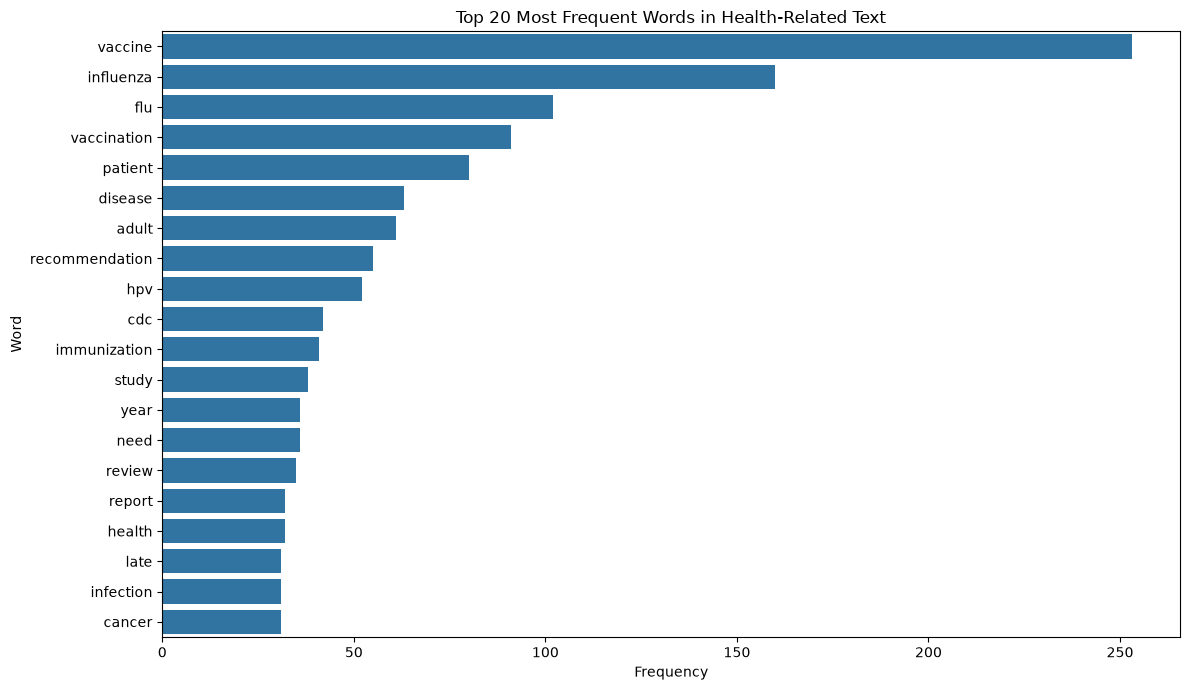

In [9]:
top20 = word_counts.most_common(20)
words = [x[0] for x in top20]
counts = [x[1] for x in top20]

plt.figure(figsize=(12, 7))
sns.barplot(x=counts, y=words)
plt.title("Top 20 Most Frequent Words in Health-Related Text")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.show()


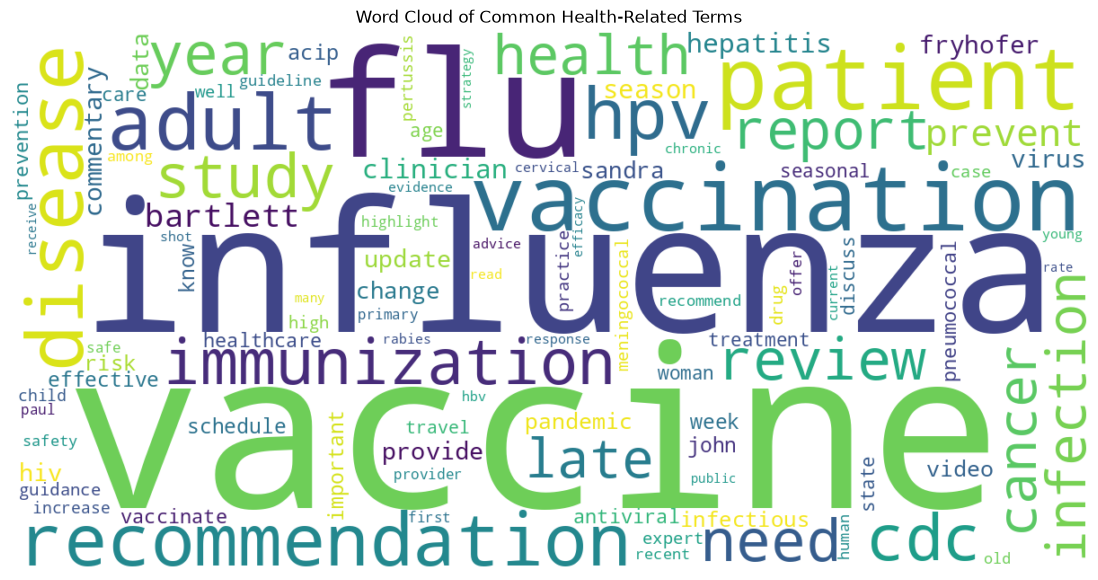

In [10]:
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=100,
    collocations=False
).generate(" ".join(all_tokens))

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Common Health-Related Terms")
plt.show()


In [11]:
NUM_TOPICS = 5
NUM_TOP_WORDS = 5

vectorizer = CountVectorizer(
    max_df=0.95,
    min_df=2,
    stop_words="english"
)

doc_term_matrix = vectorizer.fit_transform(df["clean_text"])

print("Document-term matrix shape:", doc_term_matrix.shape)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))


Document-term matrix shape: (366, 635)
Vocabulary size: 635


In [12]:
lda_model = LatentDirichletAllocation(
    n_components=NUM_TOPICS,
    random_state=42,
    learning_method="batch",
    max_iter=20
)

lda_model.fit(doc_term_matrix)

feature_names = vectorizer.get_feature_names_out()

def display_topics(model, feature_names, n_top_words=5):
    topic_rows = []
    for topic_idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[:-n_top_words - 1:-1]
        top_words = [feature_names[i] for i in top_indices]
        topic_rows.append({
            "Topic": f"Topic {topic_idx + 1}",
            "Top Words": ", ".join(top_words)
        })
    return pd.DataFrame(topic_rows)

topic_table = display_topics(
    lda_model,
    feature_names,
    n_top_words=NUM_TOP_WORDS
)

display(topic_table)


,Topic,Top Words
0,Topic 1,"patient, immunization, vaccination, hepatitis,..."
1,Topic 2,"vaccine, hpv, adult, vaccination, recommendation"
2,Topic 3,"flu, vaccine, disease, patient, shot"
3,Topic 4,"vaccine, influenza, disease, flu, review"
4,Topic 5,"influenza, vaccine, flu, vaccination, season"


In [13]:
topic_distribution = lda_model.transform(doc_term_matrix)
df["dominant_topic"] = topic_distribution.argmax(axis=1) + 1

print("Documents by dominant topic:")
display(df["dominant_topic"].value_counts().sort_index().rename("document_count").to_frame())

display(
    df[["headlines", "clean_text", "dominant_topic"]].head(15)
)


Documents by dominant topic:


,document_count
dominant_topic,
1,75
2,83
3,51
4,69
5,88


,headlines,clean_text,dominant_topic
0,"Infectious Diseases: October 30, 2004",infectious disease october bartlett review lat...,4
1,Influenza Vaccination in Pregnancy,influenza vaccination pregnancy enough family ...,2
2,Bacterial Meningitis: A Deadly But Preventable...,bacterial meningitis deadly preventable diseas...,3
3,Hepatitis Vaccination in Patients With Chronic...,hepatitis vaccination patient chronic liver di...,1
4,Emerging Infections,emerge infection john bartlett report late dat...,4
5,"New Organisms, New Drugs, New Tests, New Guide...",organism drug test guideline really need know ...,1
6,Asthma and Influenza Vaccination,asthma influenza vaccination public health bur...,1
7,Some Answers to Smallpox Vaccination Questions,answer smallpox vaccination question progress ...,1
8,Flu Vaccine for Cardiovascular Prevention in t...,flu vaccine cardiovascular prevention elderly ...,3
9,October 2002,october read drug approval hepsera chronic hep...,3


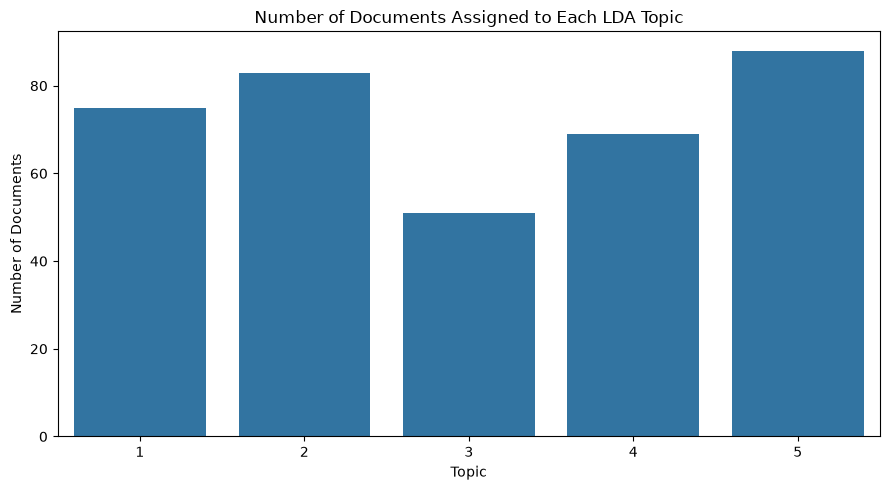

In [14]:
topic_counts = df["dominant_topic"].value_counts().sort_index()

plt.figure(figsize=(9, 5))
sns.barplot(x=topic_counts.index.astype(str), y=topic_counts.values)
plt.title("Number of Documents Assigned to Each LDA Topic")
plt.xlabel("Topic")
plt.ylabel("Number of Documents")
plt.tight_layout()
plt.show()


In [18]:
import pyLDAvis
import pyLDAvis.lda_model

pyLDAvis.enable_notebook()

lda_vis = pyLDAvis.lda_model.prepare(
    lda_model,
    doc_term_matrix,
    vectorizer,
    mds="tsne"
)

display(lda_vis)

PreparedData(topic_coordinates=               x          y  topics  cluster       Freq
topic                                                  
4     -82.324089  26.736567       1        1  23.762863
1      26.709929  53.343029       2        1  22.801242
0     -35.260979  76.943665       3        1  20.225345
3     -30.501713 -14.586076       4        1  19.802713
2      36.094444 -14.746188       5        1  13.407836, topic_info=           Term        Freq       Total Category  logprob  loglift
293   influenza  142.000000  142.000000  Default  30.0000  30.0000
262         hpv   47.000000   47.000000  Default  29.0000  29.0000
609     vaccine  224.000000  224.000000  Default  28.0000  28.0000
219         flu   90.000000   90.000000  Default  27.0000  27.0000
13        adult   55.000000   55.000000  Default  26.0000  26.0000
..          ...         ...         ...      ...      ...      ...
293   influenza    9.803630  142.165342   Topic5  -4.1717  -0.6649
278   important    4.794413   18.443555   Topic5  -4.8870   0.6621
630        year    5.196249   32.636436   Topic5  -4.8065   0.1718
493        risk    4.503157   19.359494   Topic5  -4.9497   0.5509
244  healthcare    4.145757   17.589428   Topic5  -5.0324   0.5641

[305 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
1         4  0.906944    abroad
3         2  0.752050   achieve
4         2  0.410724      acip
4         3  0.564745      acip
7         4  0.809637  activity
...     ...       ...       ...
630       3  0.122562      year
630       4  0.122562      year
630       5  0.153203      year
632       2  0.951908     young
634       5  0.902202    zoster

[446 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[5, 2, 1, 4, 3])

In [19]:
OUTPUT_PATH = "health_headlines_cleaned_with_topics.csv"

save_df = df.copy()
save_df["tokens"] = save_df["tokens"].apply(lambda x: " ".join(x))
save_df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved cleaned dataset to: {OUTPUT_PATH}")


Saved cleaned dataset to: health_headlines_cleaned_with_topics.csv
